# AI — Fine-Tune Gemma 3 270M Live Demo

End-to-end notebook: load data → fine-tune → evaluate → upload → demo

Run in Google Colab with GPU enabled: Runtime → Change runtime type → G4 GPU

Install deps (run this in a separate cell first):

```
!pip install -q torch transformers datasets trl accelerate huggingface_hub gradio rouge-score matplotlib
```

## What are we going to do?

We're going to play who's here?

A variant of Guess Who.

We'll take a base small language model (Gemma 3 270M) and fine-tune to tell us information about the guests at tonight's event.

Example input:

```
Daniel Bourke
```

Example output:

```
Daniel Bourke is a Brisbane-based Machine Learning Engineer and Instructor at Zero To Mastery, widely known for his self-taught path into the Al industry. He previously applied Al to healthcare and insurance challenges during his time at Max Kelsen. Today, he teaches thousands of students globally through his courses and popular educational platforms like learnpytorch.io. Beyond teaching, Daniel is the co-founder of the food-recognition app Nutrify and has authored a philosophical novel called 'Charlie Walks'. His YouTube channel, which documents his learning journey, has amassed over 5 million views.
Interestingly, he transitioned into tech after working as an Apple Genius and an Uber driver.
```

## Recipe

* Load dataset
* Inspect dataset
* Fine-tune model
* Evaluate model
* Upload model to Hugging Face Hub for reusability
* Create a demo application showing our model working

## Quick links

* Base model - https://huggingface.co/google/gemma-3-270m-it
* Dataset - https://huggingface.co/datasets/HuggingFaceH4/ultrachat_200k
* Base model demo - https://huggingface.co/spaces/Anup7695/ai-fine-tuned-gemma3-live
* Fine-tuned model vs base model demo - https://huggingface.co/spaces/Anup7695/ai-fine-tuned-gemma3-live

In [44]:
# # If you need to login to Hugging Face
# from huggingface_hub import notebook_login
# notebook_login()

## 0. Install Dependencies

In [1]:
!pip install -U transformers datasets trl accelerate huggingface_hub gradio rouge-score matplotlib

Check for our GPU.

In [2]:
!nvidia-smi

Sun Mar 15 08:50:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Setup quick links.


## 1. Imports + another hardware check (for fun)


In [3]:
import json
import os
import random
import time

import matplotlib.pyplot as plt
import torch
import transformers
import trl

print(f"[INFO] PyTorch version: {torch.__version__}")
print(f"[INFO] Transformers version: {transformers.__version__}")
print(f"[INFO] TRL version: {trl.__version__}")

# Check GPU
if torch.cuda.is_available():
    device = torch.cuda.current_device()
    gpu_name = torch.cuda.get_device_name(device)
    total_mem = torch.cuda.get_device_properties(device).total_memory / 1e9
    print(f"[INFO] GPU: {gpu_name} ({total_mem:.1f} GB)")
else:
    print("[WARN] No CUDA GPU detected! Training will be very slow.")
    print("[WARN] Go to Runtime → Change runtime type → T4 GPU")

[INFO] PyTorch version: 2.10.0+cu128
[INFO] Transformers version: 5.3.0
[INFO] TRL version: 0.29.0
[INFO] GPU: Tesla T4 (15.6 GB)


## 2. Setup base model

* Base model: https://huggingface.co/google/gemma-3-270m-it

> **Note:** Should you fine-tune base (`google/gemma-3-270m`) model or instruction tuned (`-it`) model? Try both. In my practice, I've found not much difference between each.

In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

MODEL_NAME = "google/gemma-3-270m-it"  # "it" = instruction-tuned

print(f"[INFO] Loading base model: {MODEL_NAME}")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager",
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"[INFO] Model loaded — dtype: {model.dtype}, device: {model.device}")
print(f"[INFO] Parameters: {sum(p.numel() for p in model.parameters()):,}")

[INFO] Loading base model: google/gemma-3-270m-it


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

[INFO] Model loaded — dtype: torch.bfloat16, device: cuda:0
[INFO] Parameters: 268,098,176


## 3. Try the base model (before fine-tuning)

In [5]:
from transformers import GenerationConfig

base_pipeline = pipeline("text-generation", model=model, tokenizer=tokenizer)

# Helper function
def pred_on_text(pipe, input_text, max_new_tokens=512):
    """Run inference and return (output_text, elapsed_seconds)."""
    gen_config = GenerationConfig(
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )
    start = time.time()
    raw = pipe(
        text_inputs=[{"role": "user", "content": input_text}],
        generation_config=gen_config,
    )
    elapsed = round(time.time() - start, 4)
    generated = raw[0]["generated_text"]
    output = generated[-1]["content"] if isinstance(generated, list) else str(generated)
    return output, elapsed

# Test with attendee names + some non-attendee names
test_inputs_before = [
    "Daniel Bourke",
    "William Bourke",
    "What are Daniel Bourke's skills?",
    "Elon Musk",
    "haiku",
]

print("=" * 70)
print("  BASE MODEL (before fine-tuning)")
print("=" * 70)
for text in test_inputs_before:
    output, elapsed = pred_on_text(base_pipeline, text)
    print(f"\n  Input:  \"{text}\"")
    print(f"  Output: {output[:200]}{'...' if len(output) > 200 else ''}")
    print(f"  ({elapsed}s)")


The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


  BASE MODEL (before fine-tuning)


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



  Input:  "Daniel Bourke"
  Output: Daniel Bourke is a well-known and respected figure in the world of **computer science and technology**. He is known for his contributions to areas such as:

*   **Artificial Intelligence (AI):** He ha...
  (8.881s)


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



  Input:  "William Bourke"
  Output: William Bourke is a well-known and influential figure in the field of **computer science and artificial intelligence**. He is known for his contributions to areas such as:

*   **Machine Learning:** H...
  (7.8377s)


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



  Input:  "What are Daniel Bourke's skills?"
  Output: Daniel Bourke is a highly accomplished and respected figure in the field of **artificial intelligence (AI)**. He has a strong background in **machine learning**, **deep learning**, and **natural langu...
  (7.6332s)


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



  Input:  "Elon Musk"
  Output: Elon Musk is a prominent figure in the world of technology and business. He is known for his ventures in various areas, including electric vehicles, space exploration, artificial intelligence, and ren...
  (1.5488s)

  Input:  "haiku"
  Output: Here's a haiku:

Green leaves softly sway,
Sunlight paints the forest floor,
Nature's gentle grace.

  (1.1755s)


## 4. Load the dataset

Dataset = what we do want our model to do? We can control it with data.

Demo:

* Take "Daniel Bourke" info and get gpt-oss-120b to create synthetic data.

Our custom dataset:

* Meetup attendee list names
* Search LinkedIn for names
* Create synthetic dataset of QA pairs based on public LinkedIn details

Your dataset:

* **Small models ideal for:** Business process that happens repeatedly (plenty of samples which often take tedious human hours to complete).
* **Large models ideal for:** Wide ranging general task that needs plenty of nuance (these use cases are as broad as software and are still be found).

**Notes:**

* Plenty of edge cases (we handle these through experimentation)
* Some names don't appear (naturally)
  * How do we handle these?
* What about names who don't appear in the Meetup attendee list (e.g. Elon Musk), what do we do with these?
  * Things you don't want in your model's behaviour are often called **hard negatives**.
    * In Nutrify's case, hard negatives would be images of things which *aren't* food.
* Why v2? Because v1 was too small (~1000 samples) so I scaled things up to ~8k.

In [6]:
from datasets import load_dataset
import random, json

DATASET_NAME = "HuggingFaceH4/ultrachat_200k"

dataset = load_dataset(DATASET_NAME)

# ✅ FIX 1: Use correct split names
train_dataset = dataset["train_sft"]
eval_dataset  = dataset["test_sft"]

print(f"[INFO] Dataset: {DATASET_NAME}")
print(f"[INFO] Train samples: {len(train_dataset)}")
print(f"[INFO] Test samples:  {len(eval_dataset)}")

# ✅ FIX 2: Use a small subset for fast iteration (optional but recommended)
train_dataset = train_dataset.select(range(3000))   # use 3k samples
eval_dataset  = eval_dataset.select(range(300))     # use 300 for eval

print(f"[INFO] Using subset → Train: {len(train_dataset)}, Eval: {len(eval_dataset)}")

README.md: 0.00B [00:00, ?B/s]

data/train_sft-00000-of-00003-a3ecf92756(…):   0%|          | 0.00/244M [00:00<?, ?B/s]

data/train_sft-00001-of-00003-0a1804bcb6(…):   0%|          | 0.00/244M [00:00<?, ?B/s]

data/train_sft-00002-of-00003-ee46ed25cf(…):   0%|          | 0.00/244M [00:00<?, ?B/s]

data/test_sft-00000-of-00001-f7dfac4afe5(…):   0%|          | 0.00/81.2M [00:00<?, ?B/s]

...

Generating train_sft split:   0%|          | 0/207865 [00:00<?, ? examples/s]

Generating test_sft split:   0%|          | 0/23110 [00:00<?, ? examples/s]

Generating train_gen split:   0%|          | 0/256032 [00:00<?, ? examples/s]

Generating test_gen split:   0%|          | 0/28304 [00:00<?, ? examples/s]

[INFO] Dataset: HuggingFaceH4/ultrachat_200k
[INFO] Train samples: 207865
[INFO] Test samples:  23110
[INFO] Using subset → Train: 3000, Eval: 300



## 5. Inspect dataset samples


In [7]:
# Show a few examples of what the model will learn
print("\n" + "=" * 70)
print("  TRAINING EXAMPLES")
print("=" * 70)

# Pick a few representative examples
for i in [0, len(train_dataset) // 4, len(train_dataset) // 2]:
    sample = train_dataset[i]
    user_msg  = sample["messages"][0]["content"]
    model_msg = sample["messages"][1]["content"]
    print(f"\n  [{i}] User:  \"{user_msg[:80]}{'...' if len(user_msg) > 80 else ''}\"")
    print(f"       Model: \"{model_msg[:120]}{'...' if len(model_msg) > 120 else ''}\"")

# Show a random example in full
random_idx    = random.randint(0, len(train_dataset) - 1)
random_sample = train_dataset[random_idx]
print(f"\n  Full random example (index {random_idx}):")
print(json.dumps(random_sample["messages"], indent=2, ensure_ascii=False))


  TRAINING EXAMPLES

  [0] User:  "These instructions apply to section-based themes (Responsive 6.0+, Retina 4.0+, ..."
       Model: "This feature only applies to Collection pages and Featured Collections sections of the section-based themes listed in th..."

  [750] User:  "Could you clarify the process of how a Minister-President is elected or appointe..."
       Model: "In a parliamentary system, a Minister-President (also known as a Prime Minister in some countries) is typically elected ..."

  [1500] User:  "What factors affect the Wi-Fi speed, and how can they be optimized to achieve th..."
       Model: "There are several factors that can affect Wi-Fi speed:

1. Distance: The farther a device is from the Wi-Fi router, the ..."

  Full random example (index 292):
[
  {
    "content": "Write a Java program that takes user input for a range of numbers, and generates a random number within that range. The program should display the randomly generated number to the user. Ensure tha

In [8]:
# Check your TRL version first
import trl
print(trl.__version__)

0.29.0


## 6. Fine-tune with SFTTrainer

SFT = Supervised Fine-tuning, examples of inputs and outputs.


In [18]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"  # reduces fragmentation
print("[INFO] Set PYTORCH_ALLOC_CONF to expandable_segments:True")

[INFO] Set PYTORCH_ALLOC_CONF to expandable_segments:True


In [20]:
from trl import SFTConfig, SFTTrainer
import torch # Import torch for clearing cache

# Function to format the dataset samples into the model's chat template
def formatting_func(example):
    # Apply the tokenizer's chat template to the 'messages' field
    # tokenize=False means it returns a string, not token IDs
    # add_generation_prompt=False because we are training on full conversations
    # The SFTTrainer will expect a dictionary with a 'text' key.
    return {"text": tokenizer.apply_chat_template(example["messages"], tokenize=False, add_generation_prompt=False)}


CHECKPOINT_DIR_NAME = "./checkpoint_models"
BASE_LEARNING_RATE = 5e-5
NUM_EPOCHS = 1
TRAIN_BATCH_SIZE = 2    # Reduced from 16 to 2
EVAL_BATCH_SIZE = 2     # Reduced from 16 to 2
GRAD_ACCUM_STEPS = 8    # Retained, effective batch size is now 2 * 8 = 16
MAX_LENGTH = 128        # Reduced from 256 to 128

torch_dtype = model.dtype

print(f"[INFO] Using dtype: {torch_dtype}")
print(f"[INFO] Epochs: {NUM_EPOCHS}")
print(f"[INFO] Learning rate: {BASE_LEARNING_RATE}")
print(f"[INFO] Train Batch size: {TRAIN_BATCH_SIZE} (effective: {TRAIN_BATCH_SIZE * GRAD_ACCUM_STEPS})")
print(f"[INFO] Max length: {MAX_LENGTH}")

sft_config = SFTConfig(
    output_dir=CHECKPOINT_DIR_NAME,
    max_length=MAX_LENGTH,
    dataset_text_field="text",
    packing=False,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS, # Add gradient accumulation steps
    gradient_checkpointing=True,                   # Enable gradient checkpointing to save memory
    optim="adamw_torch_fused",
    logging_steps=1,
    save_strategy="epoch",
    eval_strategy="epoch",
    metric_for_best_model="eval_loss",
    learning_rate=BASE_LEARNING_RATE,
    fp16=(torch_dtype == torch.float16),
    bf16=(torch_dtype == torch.bfloat16),
    lr_scheduler_type="constant",
    push_to_hub=False,
    report_to="none",
)

# Apply the formatting function explicitly to prepare the datasets
# This ensures that the 'text' field is a string and the original 'messages' field is removed
train_dataset_fmt = train_dataset.map(formatting_func, remove_columns=train_dataset.column_names)
eval_dataset_fmt = eval_dataset.map(formatting_func, remove_columns=eval_dataset.column_names)

# Clear GPU cache before training
torch.cuda.empty_cache()
print("[INFO] Cleared GPU cache.")

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset_fmt,
    eval_dataset=eval_dataset_fmt,
    processing_class=tokenizer,
)

# Train!
print(f"\n[INFO] Starting fine-tuning...")
training_start = time.time()
training_output = trainer.train()
training_time = round(time.time() - training_start, 1)

print(f"\n[INFO] Fine-tuning complete in {training_time}s!")
print(f"[INFO] Train loss: {training_output.metrics.get('train_loss', 'N/A'):.4f}")

[INFO] Using dtype: torch.bfloat16
[INFO] Epochs: 1
[INFO] Learning rate: 5e-05
[INFO] Train Batch size: 2 (effective: 16)
[INFO] Max length: 128
[INFO] Cleared GPU cache.


Truncating train dataset:   0%|          | 0/3000 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/300 [00:00<?, ? examples/s]


[INFO] Starting fine-tuning...


Epoch,Training Loss,Validation Loss
1,1.854658,2.205940


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[INFO] Fine-tuning complete in 610.0s!
[INFO] Train loss: 2.3152


## 7. Evaluate our model's loss curves

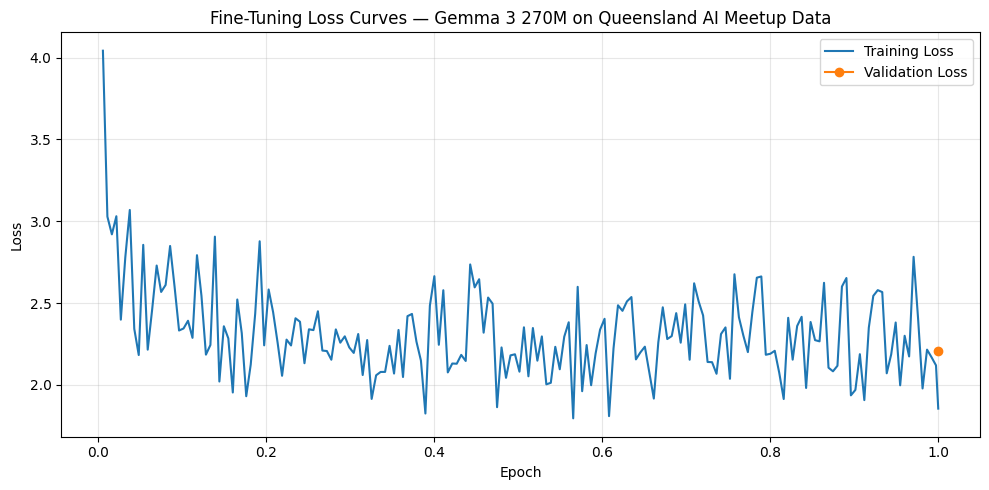

[INFO] Final eval loss: 2.2059
[INFO] Final train loss: 1.8547


In [21]:
log_history = trainer.state.log_history

train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

plt.figure(figsize=(10, 5))
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuning Loss Curves — Gemma 3 270M on Queensland AI Meetup Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()

# Print final eval loss from training log (no separate evaluate() call needed)
if eval_losses:
    print(f"[INFO] Final eval loss: {eval_losses[-1]:.4f}")
print(f"[INFO] Final train loss: {train_losses[-1]:.4f}")

## 8. Save the best model

In [22]:
trainer.save_model()
print(f"[INFO] Model saved to: {CHECKPOINT_DIR_NAME}")

# Optional: clean up checkpoint folders (keep only the final model files)
import shutil
for item in os.listdir(CHECKPOINT_DIR_NAME):
    if item.startswith("checkpoint-"):
        shutil.rmtree(os.path.join(CHECKPOINT_DIR_NAME, item))
        print(f"[INFO] Removed {item}")

print(f"[INFO] Files in {CHECKPOINT_DIR_NAME}:")
for f in sorted(os.listdir(CHECKPOINT_DIR_NAME)):
    size = os.path.getsize(os.path.join(CHECKPOINT_DIR_NAME, f)) / 1e6
    print(f"  {f:40s} {size:>8.1f} MB")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Model saved to: ./checkpoint_models
[INFO] Removed checkpoint-188
[INFO] Files in ./checkpoint_models:
  README.md                                     0.0 MB
  chat_template.jinja                           0.0 MB
  config.json                                   0.0 MB
  generation_config.json                        0.0 MB
  model.safetensors                           536.2 MB
  tokenizer.json                               33.4 MB
  tokenizer_config.json                         0.0 MB
  training_args.bin                             0.0 MB


## 9. Reload both our models (base and fine-tuned) for comparison

In [23]:
# SFTTrainer modifies `model` in-place, so `base_pipeline` now points at
# fine-tuned weights. We must reload both from scratch for a fair comparison.

import gc

# Free the training objects first
del model, trainer, base_pipeline
gc.collect()
torch.cuda.empty_cache()
print(f"[INFO] Cleared training objects from GPU memory")

# Load base model fresh (from HF Hub — original weights)
print(f"[INFO] Loading base model fresh: {MODEL_NAME}")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype="auto", device_map="auto", attn_implementation="eager")
base_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_pipe = pipeline("text-generation", model=base_model, tokenizer=base_tokenizer)

# Load fine-tuned model fresh (from checkpoint — trained weights)
print(f"[INFO] Loading fine-tuned model: {CHECKPOINT_DIR_NAME}")
ft_model = AutoModelForCausalLM.from_pretrained(
    CHECKPOINT_DIR_NAME, dtype="auto", device_map="auto", attn_implementation="eager")
ft_tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT_DIR_NAME)
ft_pipe = pipeline("text-generation", model=ft_model, tokenizer=ft_tokenizer)

print(f"[INFO] Both models loaded — ready for side-by-side comparison")

[INFO] Cleared training objects from GPU memory
[INFO] Loading base model fresh: google/gemma-3-270m-it


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

[INFO] Loading fine-tuned model: ./checkpoint_models


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

[INFO] Both models loaded — ready for side-by-side comparison


## 10. Before and after fine-tuning comparison


In [24]:
from IPython.display import display, HTML
import html as html_mod

comparison_inputs = [
    "Daniel Bourke",
    "daniel bourke",
    "William Bourke",
    "What should I ask Daniel Bourke about?",
    "What should I ask William Bourke about?",
    "Elon Musk",
    "elon musk",
    "Shrek",
    "Michael Tremeer",
    "Leah H.",
    "Adam Luff",
    "Who's here?",
]

# Display header immediately
display(HTML("""
<div style="max-width:1000px; margin:0 auto;">
  <h2 style="text-align:center; color:#fff;">🧠 Before vs After Fine-Tuning</h2>
  <p style="text-align:center; color:#fff;">Same 270M parameter model — left is base weights, right is after 2 epochs on ~7,700 training pairs</p>
</div>
"""))

# Display each card as it completes
comparison_results = []
for i, text in enumerate(comparison_inputs):
    base_out, base_time = pred_on_text(base_pipe, text)
    ft_out, ft_time = pred_on_text(ft_pipe, text)
    comparison_results.append({
        "input": text,
        "base_out": base_out,
        "base_time": base_time,
        "ft_out": ft_out,
        "ft_time": ft_time,
    })
    print(f"  [{i + 1}/{len(comparison_inputs)}] \"{text}\" done")

    # Render this card immediately
    inp = html_mod.escape(text)
    base = html_mod.escape(base_out).replace("\n", "<br>")
    ft = html_mod.escape(ft_out).replace("\n", "<br>")

    display(HTML(f"""
    <div style="max-width:1000px; margin:0 auto;">
      <div style="border:1px solid #ddd; border-radius:12px; padding:20px; margin:16px 0; background:#fafafa;">
        <div style="font-size:14px; color:#000; margin-bottom:4px;">Input</div>
        <div style="font-size:18px; font-weight:600; color:#000; padding:10px 14px; background:#fff; border:2px solid #f60; border-radius:8px; margin-bottom:16px;">{inp}</div>
        <div style="display:flex; gap:16px;">
          <div style="flex:1;">
            <div style="font-size:15px; font-weight:600; color:#000; margin-bottom:8px;">❌ Base Model <span style="font-weight:400; color:#000;">(google/gemma-3-270m-it)</span></div>
            <div style="background:#fff; border:1px solid #ddd; border-radius:8px; padding:12px; font-size:14px; line-height:1.5; min-height:80px; color:#000;">{base}</div>
            <div style="color:#000; font-size:12px; margin-top:6px;">{base_time}s</div>
          </div>
          <div style="flex:1;">
            <div style="font-size:15px; font-weight:600; color:#000; margin-bottom:8px;">✅ Fine-Tuned Model</div>
            <div style="background:#fff; border:1px solid #ddd; border-radius:8px; padding:12px; font-size:14px; line-height:1.5; min-height:80px; color:#000;">{ft}</div>
            <div style="color:#000; font-size:12px; margin-top:6px;">{ft_time}s</div>
          </div>
        </div>
      </div>
    </div>
    """))

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


  [1/12] "Daniel Bourke" done


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


  [2/12] "daniel bourke" done


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


...

  [10/12] "Leah H." done


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


  [11/12] "Adam Luff" done


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


  [12/12] "Who's here?" done


How would we improve the inputs/outputs?

What about the "Who's here?" case?

What happened there?

## 11. Evaluate on the test set (ROGUE-L score)

ROGUE-L score = a similarity measure for longest common sequence between two sequences, higher is better.

In [27]:
from tqdm.auto import tqdm
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

results = []
# Changed to use the pre-processed eval_dataset_fmt for consistency and correctness
test_data = list(eval_dataset_fmt.select(range(5))) # Refactored to take only 5 samples

print(f"\n[INFO] Evaluating on {len(test_data)} test samples...")

for i, row in tqdm(enumerate(test_data), desc="Evaluating test samples", total=len(test_data)):
    # The 'text' field now contains the full chat template string including both user and assistant parts
    # We need to parse this to separate the input (user) from the expected output (assistant)
    # This assumes the chat template produces a predictable structure, e.g., 'User: ... Assistant: ...'

    # A more robust way would be to keep original 'messages' in eval_dataset and format on the fly
    # or use a regex to extract input/output from the formatted 'text'.
    # For now, let's assume 'text' contains the full conversation, and we want to evaluate the last turn.

    # Example of how to extract based on a simple prompt/response structure from the `formatting_func`
    # Given `tokenizer.apply_chat_template(example["messages"], tokenize=False, add_generation_prompt=False)`
    # The format will be something like: <bos>User: user_msg Assistant: assistant_msg<eos>

    # For ROUGE, we need the model's actual input and the ground truth expected output.
    # The `eval_dataset_fmt` contains the full formatted conversation string.
    # We need the original `eval_dataset`'s messages to extract the true input and output.

    original_sample = eval_dataset[i] # Access the original sample before formatting
    input_text = original_sample["messages"][0]["content"] # Original user message
    expected = original_sample["messages"][1]["content"] # Original assistant message

    predicted, elapsed = pred_on_text(ft_pipe, input_text)

    rouge = scorer.score(expected, predicted)["rougeL"].fmeasure
    results.append({"input": input_text, "rouge_l": rouge, "elapsed": elapsed})

    if (i + 1) % 25 == 0:
        print(f"  [{i+1}/{len(test_data)}] processed...")

# Summary
rouge_scores = [r["rouge_l"] for r in results]
exact = sum(1 for s in rouge_scores if s >= 0.99)
passed = sum(1 for s in rouge_scores if 0.5 <= s < 0.99)
partial = sum(1 for s in rouge_scores if 0.2 <= s < 0.5)
failed = sum(1 for s in rouge_scores if s < 0.2)

total = len(results)
print(f"\n{'='*60}")
print(f"  Evaluation Summary")
print(f"{'='*60}")
print(f"  Total samples  : {total}")
print(f"  Exact match    : {exact} ({exact/total:.1%})")
print(f"  Pass (\u22650.5)    : {passed} ({passed/total:.1%})")
print(f"  Partial (\u22650.2) : {partial} ({partial/total:.1%})")
print(f"  Fail (<0.2)    : {failed} ({failed/total:.1%})")
print(f"  Pass+Exact rate: {(exact+passed)/total:.1%}")
print(f"  ROUGE-L mean   : {sum(rouge_scores)/total:.3f}")
print(f"  ROUGE-L median : {sorted(rouge_scores)[total//2]:.3f}")


[INFO] Evaluating on 5 test samples...


Evaluating test samples:   0%|          | 0/5 [00:00<?, ?it/s]


  Evaluation Summary
  Total samples  : 5
  Exact match    : 0 (0.0%)
  Pass (≥0.5)    : 0 (0.0%)
  Partial (≥0.2) : 1 (20.0%)
  Fail (<0.2)    : 4 (80.0%)
  Pass+Exact rate: 0.0%
  ROUGE-L mean   : 0.203
  ROUGE-L median : 0.186


## 12. Upload the fine-tuned model to Hugging Face Hub

Let's make our artifacts reusable so we can access them whenever we need.

In [28]:
from huggingface_hub import login, HfApi, create_repo
from google.colab import userdata # Import userdata

# ✅ Replace with your NEW write-enabled token (or add to Colab secrets)
HF_TOKEN = userdata.get("HF_TOKEN") # Get token from Colab secrets

if not HF_TOKEN:
    print("[ERROR] Hugging Face token not found. Please add it to Colab secrets as 'HF_TOKEN'.")

# Only attempt login if token is available
if HF_TOKEN:
    login(token=HF_TOKEN)
    print("[INFO] Logged in to HuggingFace ✅")
else:
    print("[WARN] Skipping HuggingFace login and model upload due to missing token.")


# ── Config ────────────────────────────────────────────────────────────────────
HF_USERNAME   = "Anup7695"
MODEL_SUFFIX  = "live"
MODEL_REPO_ID = f"{HF_USERNAME}/gemma3-270m-finetuned-ultrachat-{MODEL_SUFFIX}"

# Define SUFFIX for the README and SPACE_NAME/full_repo_name for the demo app
SUFFIX = MODEL_SUFFIX
SPACE_NAME = f"{HF_USERNAME}/gemma3-270m-finetuned-ultrachat-space-{MODEL_SUFFIX}" # Name for the Hugging Face Space
full_repo_name = SPACE_NAME # Using full_repo_name for consistency with example notebooks

api = HfApi()

if HF_TOKEN: # Only proceed with repo creation/upload if token is available
    # ── Create model repo ─────────────────────────────────────────────────────────
    print(f"[INFO] Creating model repo: {MODEL_REPO_ID}")
    try:
        create_repo(
            repo_id=MODEL_REPO_ID,
            repo_type="model",
            exist_ok=True,
            token=HF_TOKEN,       # ✅ pass token explicitly
        )
        print(f"[INFO] Model repository '{MODEL_REPO_ID}' created or already exists.")
    except Exception as e:
        print(f"[ERROR] Failed to create or access model repository '{MODEL_REPO_ID}': {e}")

    # ── Upload checkpoint ─────────────────────────────────────────────────────────
    print(f"[INFO] Uploading from: {CHECKPOINT_DIR_NAME}")
    try:
        api.upload_folder(
            folder_path=CHECKPOINT_DIR_NAME,
            repo_id=MODEL_REPO_ID,
            repo_type="model",
            token=HF_TOKEN,       # ✅ pass token explicitly
        )
        print(f"\n[INFO] ✅ Model uploaded successfully!")
        print(f"[INFO] View at: https://huggingface.co/{MODEL_REPO_ID}")
    except Exception as e:
        print(f"[ERROR] Failed to upload model to '{MODEL_REPO_ID}': {e}")
else:
    print("[WARN] Skipping HuggingFace model repo creation and upload due to missing token.")

[INFO] Logged in to HuggingFace ✅
[INFO] Creating model repo: Anup7695/gemma3-270m-finetuned-ultrachat-live
[INFO] Model repository 'Anup7695/gemma3-270m-finetuned-ultrachat-live' created or already exists.
[INFO] Uploading from: ./checkpoint_models


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...int_models/tokenizer.json:  47%|####6     | 15.7MB / 33.4MB            

  ..._models/model.safetensors:   0%|          |  600kB /  536MB            

  ..._models/training_args.bin:   1%|          |  50.0B / 5.65kB            


[INFO] ✅ Model uploaded successfully!
[INFO] View at: https://huggingface.co/Anup7695/gemma3-270m-finetuned-ultrachat-live


## 13. Create Gradio demo comparison app (base model vs fine-tuned)

One of the best things you can do is create a comparison tool (e.g. simple web app or Gradio) to showcase actual examples side by side with different variations/models.

In [38]:
os.makedirs("demos/comparison", exist_ok=True)

# Write app.py
app_py = '''"""
AI Comparison  — Base vs Fine-Tuned Gemma 3 270M
Side-by-side comparison: same input goes to both models.
"""

import time
import gradio as gr
import spaces
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig, pipeline
import os # Import os to get environment variables
from huggingface_hub import login # Import login for authentication

BASE_MODEL_NAME = "google/gemma-3-270m-it"
FINE_TUNED_MODEL_NAME = "''' + MODEL_REPO_ID + '''"

# Get Hugging Face token from environment variables (Colab secrets or Space secrets)
HF_TOKEN = os.environ.get("HF_TOKEN")

# Log in to Hugging Face if token is available
if HF_TOKEN:
    try:
        login(token=HF_TOKEN)
        print("[INFO] Logged in to HuggingFace for Gradio App")
    except Exception as e:
        print(f"[WARN] Failed to log in to HuggingFace in Gradio App: {e}")
else:
    print("[WARN] HF_TOKEN environment variable not set. This may cause issues with gated models.")

print("[INFO] Loading base model...")
# Add explicit check for gated model and missing token
if not HF_TOKEN and BASE_MODEL_NAME.lower() == "google/gemma-3-270m-it":
    print("[ERROR] Base model 'google/gemma-3-270m-it' is gated and HF_TOKEN is missing. Please ensure HF_TOKEN is set as a Space secret.")

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME, dtype="auto", device_map="auto", attn_implementation="eager", token=HF_TOKEN)
base_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME, token=HF_TOKEN)
base_pipe = pipeline("text-generation", model=base_model, tokenizer=base_tokenizer)

print("[INFO] Loading fine-tuned model...")
ft_model = AutoModelForCausalLM.from_pretrained(
    FINE_TUNED_MODEL_NAME, dtype="auto", device_map="auto", attn_implementation="eager", token=HF_TOKEN)
ft_tokenizer = AutoTokenizer.from_pretrained(FINE_TUNED_MODEL_NAME, token=HF_TOKEN)
ft_pipe = pipeline("text-generation", model=ft_model, tokenizer=ft_tokenizer)
print("[INFO] Both models loaded!")

def run_model(pipe, input_text, max_new_tokens=512):
    gen_config = GenerationConfig(max_new_tokens=max_new_tokens, do_sample=False)
    start_time = time.time()
    raw_output = pipe(
        text_inputs=[{"role": "user", "content": input_text}],
        generation_config=gen_config)
    elapsed = round(time.time() - start_time, 4)
    generated = raw_output[0]["generated_text"]
    output_text = generated[-1]["content"] if isinstance(generated, list) else str(generated)
    return output_text, elapsed

@spaces.GPU
def compare(input_text):
    base_output, base_time = run_model(base_pipe, input_text)
    ft_output, ft_time = run_model(ft_pipe, input_text)
    return base_output, base_time, ft_output, ft_time

description = """## Base vs Fine-Tuned Gemma 3 270M

Type a name or question and see both models respond.

**Try:** `Daniel Bourke`, `daniel bourke`, `Elon Musk`, `Shrek`, `Leah H.`
"""

with gr.Blocks(title="AI — Base vs Fine-Tuned") as demo:
    gr.Markdown("# Base vs Fine-Tuned Gemma 3 270M")
    gr.Markdown(description)
    with gr.Row():
        input_text = gr.Textbox(lines=2, label="Type a name or question",
                                placeholder="e.g. Daniel Bourke", scale=3)
        submit_btn = gr.Button("Compare", variant="primary", scale=1)
    with gr.Row():
        with gr.Column():
            gr.Markdown("### Base Model (google/gemma-3-270m-it)")
            base_output = gr.Textbox(lines=12, label="Base Model Output", interactive=False)
            base_time = gr.Number(label="Base Time (s)")
        with gr.Column():
            gr.Markdown("### Fine-Tuned Model")
            ft_output = gr.Textbox(lines=12, label="Fine-Tuned Output", interactive=False)
            ft_time = gr.Number(label="Fine-Tuned Time (s)")
    submit_btn.click(fn=compare, inputs=[input_text],
                     outputs=[base_output, base_time, ft_output, ft_time])
    input_text.submit(fn=compare, inputs=[input_text],
                      outputs=[base_output, base_time, ft_output, ft_time])
    gr.Examples(
        examples=[["Daniel Bourke"], ["daniel bourke"], ["William Bourke"],
                  ["What are Daniel Bourke's skills?"], ["Adam Luff"],
                  ["Elon Musk"], ["Shrek"], ["haiku"], ["Leah H."]],
        inputs=input_text)

if __name__ == "__main__":
    demo.launch()
'''

with open("demos/comparison/app.py", "w") as f:
    f.write(app_py)
print("[INFO] Written demos/comparison/app.py")

# Write README.md
readme = f"""---
title: AI — Base vs Fine-Tuned Gemma 3 270M - {SUFFIX}
emoji: 🧠⚡
colorFrom: red
colorTo: green
sdk: gradio
app_file: app.py
pinned: false
license: apache-2.0
---

Side-by-side comparison of base Gemma 3 270M vs fine-tuned .
"""

with open("demos/comparison/README.md", "w") as f:
    f.write(readme)
print("[INFO] Written demos/comparison/README.md")

# Write requirements.txt
with open("demos/comparison/requirements.txt", "w") as f:
    f.write("transformers\ngradio\ntorch\naccelerate\nhuggingface_hub\n") # Added huggingface_hub
print("[INFO] Written demos/comparison/requirements.txt")

[INFO] Written demos/comparison/app.py
[INFO] Written demos/comparison/README.md
[INFO] Written demos/comparison/requirements.txt


In [39]:
print(f"[INFO] This is our README:")
print(readme)

[INFO] This is our README:
---
title: AI — Base vs Fine-Tuned Gemma 3 270M - live
emoji: 🧠⚡
colorFrom: red
colorTo: green
sdk: gradio
app_file: app.py
pinned: false
license: apache-2.0
---

Side-by-side comparison of base Gemma 3 270M vs fine-tuned .



## 14. Upload comparison demo to Hugging Face Spaces


In [40]:
from huggingface_hub import create_repo, get_full_repo_name, upload_folder

SPACE_NAME = f"ai-fine-tuned-gemma3-{SUFFIX}"
LOCAL_DEMO_FOLDER = "demos/comparison/"

print(f"[INFO] Creating Space: {SPACE_NAME}")
create_repo(
    repo_id=SPACE_NAME,
    repo_type="space",
    space_sdk="gradio",
    exist_ok=True,
)

full_repo_name = get_full_repo_name(model_id=SPACE_NAME)
print(f"[INFO] Full Space name: {full_repo_name}")

print(f"[INFO] Uploading {LOCAL_DEMO_FOLDER}...")
folder_url = upload_folder(
    repo_id=full_repo_name,
    folder_path=LOCAL_DEMO_FOLDER,
    path_in_repo=".",
    repo_type="space",
    commit_message="Upload AI comparison demo",
)
print(f"[INFO] ✓ Space uploaded: https://huggingface.co/spaces/{full_repo_name}")

[INFO] Creating Space: ai-fine-tuned-gemma3-live
[INFO] Full Space name: Anup7695/ai-fine-tuned-gemma3-live
[INFO] Uploading demos/comparison/...
[INFO] ✓ Space uploaded: https://huggingface.co/spaces/Anup7695/ai-fine-tuned-gemma3-live


## 15. Show the demo application in the notebook

In [41]:
from IPython.display import HTML

html_code = f"""<iframe
    src="https://{full_repo_name.replace('/', '-')}.hf.space"
    frameborder="0"
    width="100%"
    height="800"
></iframe>"""

print(f"[INFO] Space URL: https://huggingface.co/spaces/{full_repo_name}")
print(f"[INFO] Direct URL: https://{full_repo_name.replace('/', '-')}.hf.space")
HTML(html_code)

[INFO] Space URL: https://huggingface.co/spaces/Anup7695/ai-fine-tuned-gemma3-live
[INFO] Direct URL: https://Anup7695-ai-fine-tuned-gemma3-live.hf.space


## 16. Summary

In [46]:
print(f"""
{'='*60}
  AI — Fine-Tuning Demo Complete!
{'='*60}

  Base model       : {MODEL_NAME}
  Dataset          : {DATASET_NAME}
  Training pairs   : {len(dataset['train_sft'])}
  Test pairs       : {len(dataset['test_sft'])}
  Epochs           : {NUM_EPOCHS}
  Training time    : {training_time}s
  ROUGE-L mean     : {sum(rouge_scores)/total:.3f}
  Pass+Exact rate  : {(exact+passed)/total:.1%}

  Model uploaded to: https://huggingface.co/{MODEL_REPO_ID}
  Space uploaded to: https://huggingface.co/spaces/{full_repo_name}

{'='*60}
""")


  AI — Fine-Tuning Demo Complete!

  Base model       : google/gemma-3-270m-it
  Dataset          : HuggingFaceH4/ultrachat_200k
  Training pairs   : 207865
  Test pairs       : 23110
  Epochs           : 1
  Training time    : 610.0s
  ROUGE-L mean     : 0.203
  Pass+Exact rate  : 0.0%

  Model uploaded to: https://huggingface.co/Anup7695/gemma3-270m-finetuned-ultrachat-live
  Space uploaded to: https://huggingface.co/spaces/Anup7695/ai-fine-tuned-gemma3-live


